# 03 · p-adic basics: Q_p, balls, and Hensel lifting

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mircus/padics/blob/master/notebooks/03_padic_basics.ipynb)
[![View on nbviewer](https://raw.githubusercontent.com/jupyter/design/master/logos/Badges/nbviewer_badge.svg)](https://nbviewer.org/github/Mircus/padics/blob/master/notebooks/03_padic_basics.ipynb)

Demonstrates the core arithmetic of `padic-ds`: embedding integers and rationals into Q_p, computing absolute values and distances, constructing p-adic balls, and using Hensel lifting to find roots modulo prime powers.

In [1]:
# Install padic-ds (skip if already installed)
import importlib, subprocess, sys
if importlib.util.find_spec('padic') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'git+https://github.com/Mircus/padics.git'])


In [2]:
from padic import QpContext, Qp, QpBall, hensel_lift_simple, padic_abs, padic_dist

ctx = QpContext(p=3, prec=8)
x = Qp.from_rational(ctx, 7, 12)   # 7/12 in Q_3
y = Qp.from_int(ctx, 10)            # 10 in Q_3
print('x =', x)
print('y =', y)
print('|x|_3 =', x.abs())
print('|y|_3 =', y.abs())
print('d_3(x,y) =', padic_dist(x, y))


x = Qp(u≡1642 (mod 3^8) * 3^-1; p=3)
y = Qp(u≡10 (mod 3^8) * 3^0; p=3)
|x|_3 = 3.0
|y|_3 = 1.0
d_3(x,y) = 3.0


## Hensel lifting example

In [3]:
# f(X) = X^2 - 6 in Z_5
# 1^2 - 6 = -5 ≡ 0 mod 5, f'(1) = 2 ≢ 0 mod 5  → Hensel applies
ctx5 = QpContext(5, prec=10)
root = hensel_lift_simple(ctx5, lambda t: t*t - 6, lambda t: 2*t,
                          a0_mod_p=1, target_prec=10)
check = root.mul(root).sub(Qp.from_int(ctx5, 6))
print('root  =', root)
print('|root|_5 =', root.abs())
print('root^2 - 6 =', check, '  |·|_5 =', check.abs())


root  = Qp(u≡6520516 (mod 5^10) * 5^0; p=5)
|root|_5 = 1.0
root^2 - 6 = Qp(0; p=5, prec=10)   |·|_5 = 0.0


## Balls and refinements

In [4]:
B = QpBall(x, n=2)    # Ball of radius 3^{-2} around x
subs = B.refine()     # Partition into 3 sub-balls
print('Parent ball:', B)
print('Number of sub-balls:', len(subs))
for s in subs:
    print(' ', s)


Parent ball: B(Qp(u≡1642 (mod 3^8) * 3^-1; p=3), p^(-2))
Number of sub-balls: 3
  B(Qp(u≡1642 (mod 3^8) * 3^-1; p=3), p^(-3))
  B(Qp(u≡1669 (mod 3^8) * 3^-1; p=3), p^(-3))
  B(Qp(u≡1696 (mod 3^8) * 3^-1; p=3), p^(-3))


## Distance table for several primes

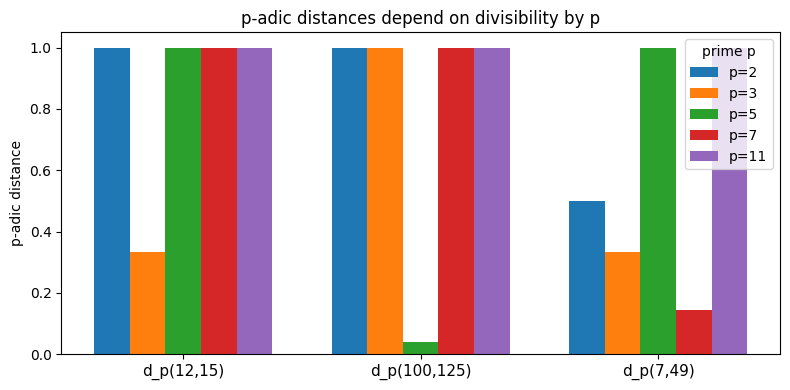

Done.


In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

primes = [2, 3, 5, 7, 11]
pairs  = [(12, 15), (100, 125), (7, 49)]

fig, ax = plt.subplots(figsize=(8, 4))
x_pos = np.arange(len(pairs))
width = 0.15
for i, p in enumerate(primes):
    c = QpContext(p, prec=10)
    dists = []
    for (a, b) in pairs:
        try:
            da = Qp.from_int(c, a)
            db = Qp.from_int(c, b)
            dists.append(padic_dist(da, db))
        except Exception:
            dists.append(float('nan'))
    ax.bar(x_pos + i*width, dists, width=width, label=f'p={p}')

ax.set_xticks(x_pos + 2*width)
ax.set_xticklabels([f'd_p({a},{b})' for a,b in pairs], fontsize=11)
ax.set_ylabel('p-adic distance')
ax.set_title('p-adic distances depend on divisibility by p', fontsize=12)
ax.legend(title='prime p')
plt.tight_layout()
plt.savefig('padic_dist_primes.png', dpi=110, bbox_inches='tight')
plt.show()
print('Done.')
